In [37]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize


from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, precision_recall_curve, roc_curve, roc_auc_score
)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import classification_report



In [38]:
# %% Carregar datasets já divididos
train_df = pd.read_csv("data/train.csv")
val_df   = pd.read_csv("data/val.csv")
test_df  = pd.read_csv("data/test.csv")

In [39]:

target = "TriageGrade"

y_test = val_df[target]


In [40]:
def evaluate_model(model, X, y):
    preds = model.predict(X)
    # Gera o relatório como dicionário para extrair métricas por classe
    report = classification_report(y, preds, output_dict=True, zero_division=0)

    return {
        "accuracy": accuracy_score(y, preds),
        "precision": precision_score(y, preds, average="weighted", zero_division=0),
        "recall": recall_score(y, preds, average="weighted", zero_division=0),
        "f1": f1_score(y, preds, average="weighted", zero_division=0),
        # Extrai o recall da classe 5 (ajusta para 5 ou '5' conforme o teu dataset)
        "recall_class_5": report.get('5', report.get(5, {})).get('recall', 0),
        "preds": preds
    }


In [41]:
def recall_per_class(y_true, y_pred, model_name):
    # Gera o relatório como dicionário para acesso programático [1, 2]
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)

    data = []
    # np.unique identifica todas as classes reais presentes no dataset [3, 4]
    for label in np.unique(y_true).astype(str):
        if label in report:
            data.append({
                "model": model_name,
                "class": label,
                "recall": report[label]['recall'] # Extrai o recall individual da classe [1]
            })
    return data


In [42]:
def plot_cm(y, preds, name):
    cm = confusion_matrix(y, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


In [43]:
def plot_cm_normalized(y, preds, name):
    # O parâmetro normalize='true' divide os valores pelo total de cada classe real (linhas)
    cm = confusion_matrix(y, preds, normalize='true')
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=".2%", cmap="Blues")
    plt.title(f"Matriz de Confusão Normalizada - {name}")
    plt.xlabel("Previsto")
    plt.ylabel("Real")
    plt.show()


In [44]:
from sklearn.preprocessing import label_binarize

def plot_pr_curve_class_5(y_test, probas, model_name, class_label=5):
    # Binarizar para a classe específica
    classes = np.unique(y_test)
    y_bin = label_binarize(y_test, classes=classes)

    # Encontrar o índice da classe 5
    class_idx = list(classes).index(class_label)

    # Extrair probabilidades apenas para a classe 5
    precision, recall, _ = precision_recall_curve(y_bin[:, class_idx], probas[:, class_idx])

    plt.plot(recall, precision, label=f"{model_name} (Classe {class_label})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Curva Precision-Recall - Classe 5")
    plt.legend()


In [45]:
def plot_threshold_analysis(y_test, probas, model_name, class_label=5):
    classes = np.unique(y_test)
    class_idx = list(classes).index(class_label)
    probs_class_5 = probas[:, class_idx]
    y_true_binary = (y_test == class_label).astype(int)

    thresholds = np.linspace(0, 1, 100)
    recalls = []
    precisions = []

    for th in thresholds:
        th_preds = (probs_class_5 >= th).astype(int)
        recalls.append(recall_score(y_true_binary, th_preds, zero_division=0))
        precisions.append(precision_score(y_true_binary, th_preds, zero_division=0))

    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, recalls, label="Recall (Classe 5)")
    plt.plot(thresholds, precisions, label="Precision (Classe 5)")
    plt.axvline(0.5, color="red", linestyle="--", label="Threshold Padrão (0.5)")
    plt.xlabel("Limiar de Decisão (Threshold)")
    plt.ylabel("Score")
    plt.title(f"Análise de Limiar - {model_name}")
    plt.legend()
    plt.grid(True)
    plt.show()


In [46]:
def multiclass_auc(y, probas):
    classes = np.unique(y)
    y_bin = label_binarize(y, classes=classes)

    return roc_auc_score(
        y_bin,
        probas,
        average="macro",
        multi_class="ovr"
    )

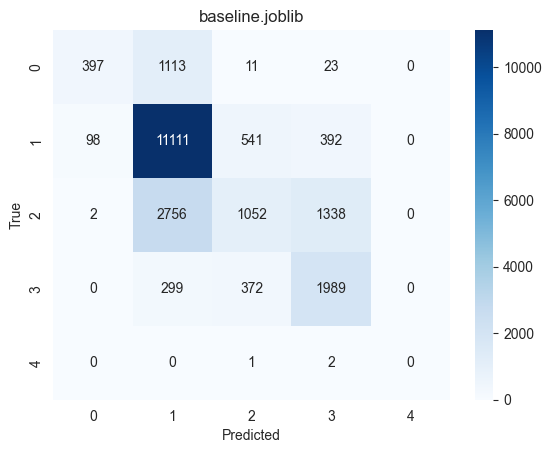

Relatório para baseline.joblib:
              precision    recall  f1-score   support

           1       0.80      0.26      0.39      1544
           2       0.73      0.92      0.81     12142
           3       0.53      0.20      0.30      5148
           4       0.53      0.75      0.62      2660
           5       0.00      0.00      0.00         3

    accuracy                           0.68     21497
   macro avg       0.52      0.42      0.42     21497
weighted avg       0.66      0.68      0.63     21497



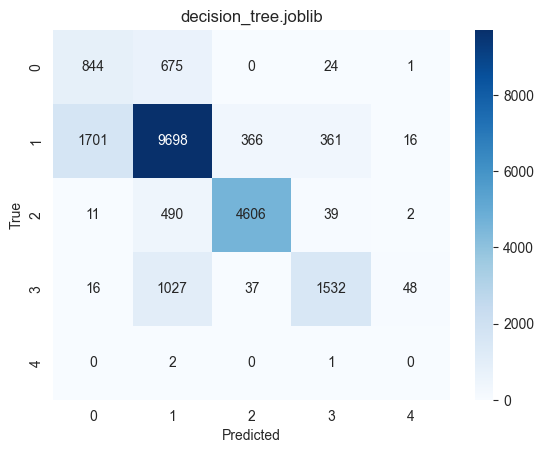

Relatório para decision_tree.joblib:
              precision    recall  f1-score   support

           1       0.33      0.55      0.41      1544
           2       0.82      0.80      0.81     12142
           3       0.92      0.89      0.91      5148
           4       0.78      0.58      0.66      2660
           5       0.00      0.00      0.00         3

    accuracy                           0.78     21497
   macro avg       0.57      0.56      0.56     21497
weighted avg       0.80      0.78      0.78     21497



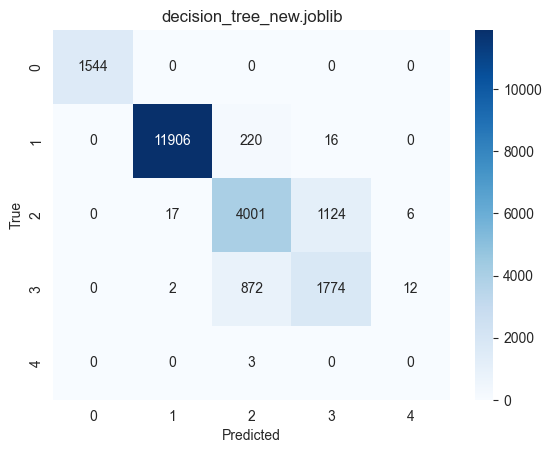

Relatório para decision_tree_new.joblib:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      1544
           2       1.00      0.98      0.99     12142
           3       0.79      0.78      0.78      5148
           4       0.61      0.67      0.64      2660
           5       0.00      0.00      0.00         3

    accuracy                           0.89     21497
   macro avg       0.68      0.68      0.68     21497
weighted avg       0.90      0.89      0.90     21497



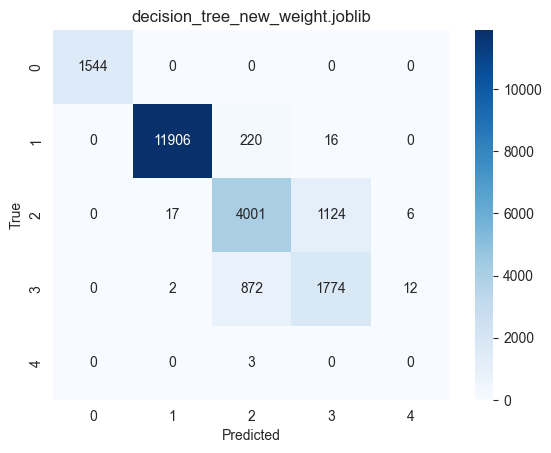

Relatório para decision_tree_new_weight.joblib:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      1544
           2       1.00      0.98      0.99     12142
           3       0.79      0.78      0.78      5148
           4       0.61      0.67      0.64      2660
           5       0.00      0.00      0.00         3

    accuracy                           0.89     21497
   macro avg       0.68      0.68      0.68     21497
weighted avg       0.90      0.89      0.90     21497



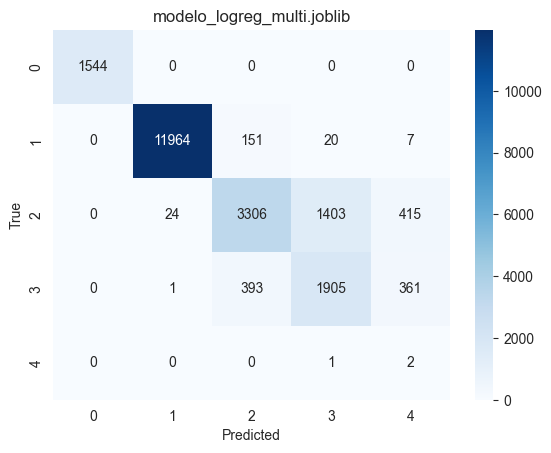

Relatório para modelo_logreg_multi.joblib:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      1544
           2       1.00      0.99      0.99     12142
           3       0.86      0.64      0.73      5148
           4       0.57      0.72      0.64      2660
           5       0.00      0.67      0.01         3

    accuracy                           0.87     21497
   macro avg       0.69      0.80      0.67     21497
weighted avg       0.91      0.87      0.89     21497



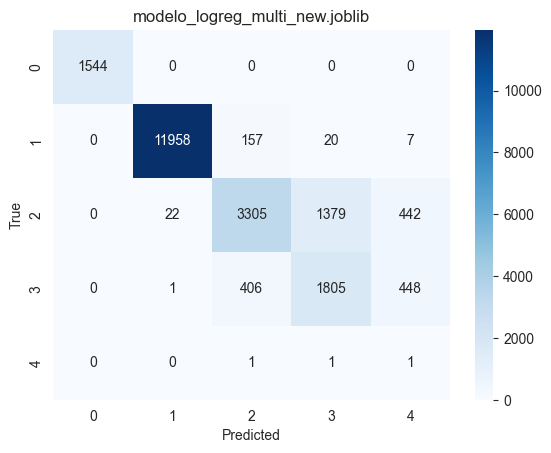

Relatório para modelo_logreg_multi_new.joblib:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      1544
           2       1.00      0.98      0.99     12142
           3       0.85      0.64      0.73      5148
           4       0.56      0.68      0.62      2660
           5       0.00      0.33      0.00         3

    accuracy                           0.87     21497
   macro avg       0.68      0.73      0.67     21497
weighted avg       0.91      0.87      0.88     21497



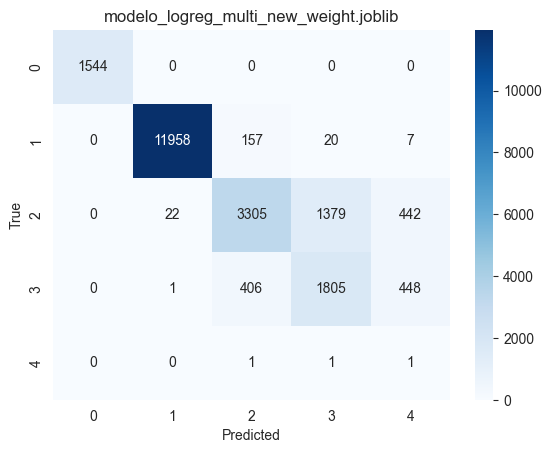

Relatório para modelo_logreg_multi_new_weight.joblib:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      1544
           2       1.00      0.98      0.99     12142
           3       0.85      0.64      0.73      5148
           4       0.56      0.68      0.62      2660
           5       0.00      0.33      0.00         3

    accuracy                           0.87     21497
   macro avg       0.68      0.73      0.67     21497
weighted avg       0.91      0.87      0.88     21497



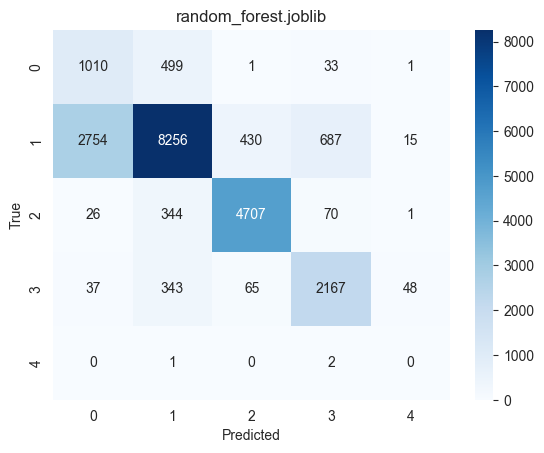

Relatório para random_forest.joblib:
              precision    recall  f1-score   support

           1       0.26      0.65      0.38      1544
           2       0.87      0.68      0.76     12142
           3       0.90      0.91      0.91      5148
           4       0.73      0.81      0.77      2660
           5       0.00      0.00      0.00         3

    accuracy                           0.75     21497
   macro avg       0.56      0.61      0.56     21497
weighted avg       0.82      0.75      0.77     21497



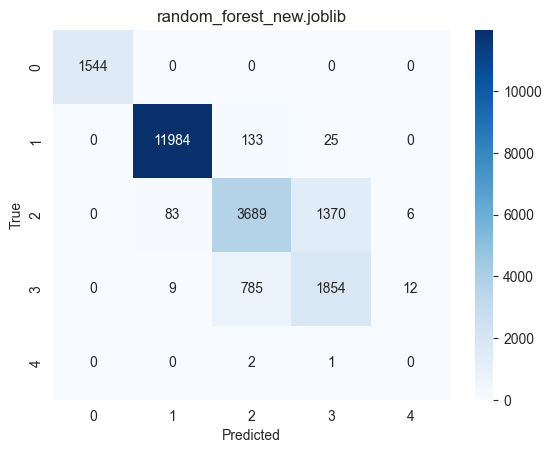

Relatório para random_forest_new.joblib:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      1544
           2       0.99      0.99      0.99     12142
           3       0.80      0.72      0.76      5148
           4       0.57      0.70      0.63      2660
           5       0.00      0.00      0.00         3

    accuracy                           0.89     21497
   macro avg       0.67      0.68      0.67     21497
weighted avg       0.89      0.89      0.89     21497



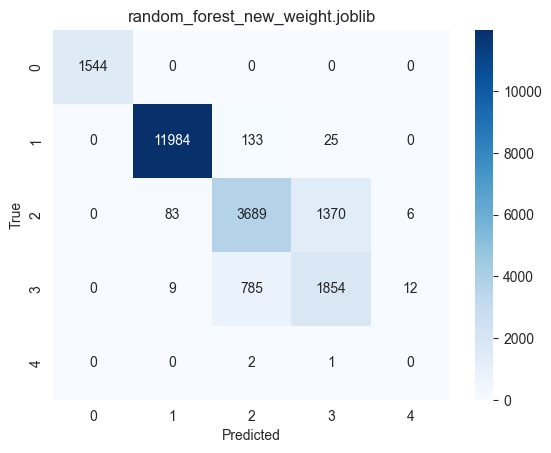

Relatório para random_forest_new_weight.joblib:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      1544
           2       0.99      0.99      0.99     12142
           3       0.80      0.72      0.76      5148
           4       0.57      0.70      0.63      2660
           5       0.00      0.00      0.00         3

    accuracy                           0.89     21497
   macro avg       0.67      0.68      0.67     21497
weighted avg       0.89      0.89      0.89     21497



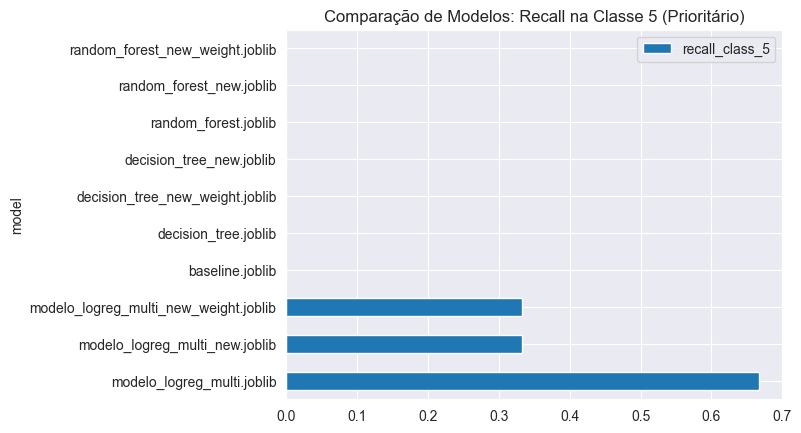

In [47]:
models_to_test = [
    "models/models/baseline.joblib",
    "models/models/decision_tree.joblib",
    "models/models/decision_tree_new.joblib",
    "models/models/decision_tree_new_weight.joblib",
    "models/models/modelo_logreg_multi.joblib",
    "models/models/modelo_logreg_multi_new.joblib",
    "models/models/modelo_logreg_multi_new_weight.joblib",
    'models/models/random_forest.joblib',
    'models/models/random_forest_new.joblib',
    'models/models/random_forest_new_weight.joblib',
]

auc_results = []
results =[]
recall_per_class_data = [] # Corrigido: Inicialização necessária [1]

for path in models_to_test:
    data = joblib.load(path)
    model = data["model"]
    features = data["features"]
    name = path.split("/")[-1]

    # Seleção de features simplificada
    X_test_model = val_df[features] # Corrigido: Removida redundância [1]

    # Obtenção de predições e probabilidades
    preds = model.predict(X_test_model)
    probas = model.predict_proba(X_test_model)

    # Cálculo das métricas
    auc = multiclass_auc(y_test, probas)
    out = evaluate_model(model, X_test_model, y_test)

    # Relatório detalhado para extração de recall por classe
    report = classification_report(y_test, preds, output_dict=True, zero_division=0)

    # Coleta de recall individual por classe para o gráfico de barras
    for label in np.unique(y_test).astype(str):
        if label in report:
            recall_per_class_data.append({
                "model": name,
                "class": f"Classe {label}",
                "recall": report[label]['recall'] # Extrai o recall individual [7]
            })

    # Armazenamento dos resultados gerais
    results.append({
        "model": name,
        "accuracy": out["accuracy"],
        "precision": out["precision"],
        "recall": out["recall"],
        "f1": out["f1"],
        "recall_class_5": out["recall_class_5"] # Métrica prioritária [7]
    })

    auc_results.append({
        "model": name,
        "auc_macro_ovr": auc
    })

    # Visualização imediata por modelo
    plot_cm(y_test, preds, name) # Usando preds já calculados
    print(f"Relatório para {name}:")
    print(classification_report(y_test, preds, zero_division=0))

# Criação dos DataFrames finais após o loop
df_recalls_all = pd.DataFrame(recall_per_class_data)
df_comp = pd.DataFrame(results)
df_comp.sort_values("recall_class_5", ascending=False).plot(x="model", y="recall_class_5", kind="barh")
plt.title("Comparação de Modelos: Recall na Classe 5 (Prioritário)")
plt.show()



In [48]:
df_results = pd.DataFrame(results)
df_results.sort_values("recall_class_5", ascending=False)



,model,accuracy,precision,recall,f1,recall_class_5
4,modelo_logreg_multi.joblib,0.870866,0.911916,0.870866,0.886588,0.666667
5,modelo_logreg_multi_new.joblib,0.865842,0.909816,0.865842,0.883513,0.333333
6,modelo_logreg_multi_new_weight.joblib,0.865842,0.909816,0.865842,0.883513,0.333333
0,baseline.joblib,0.676792,0.661281,0.676792,0.633254,0.000000
1,decision_tree.joblib,0.775922,0.801260,0.775922,0.784592,0.000000
3,decision_tree_new_weight.joblib,0.894311,0.899095,0.894311,0.896489,0.000000
2,decision_tree_new.joblib,0.894311,0.899095,0.894311,0.896489,0.000000
7,random_forest.joblib,0.750802,0.820044,0.750802,0.772326,0.000000
8,random_forest_new.joblib,0.887147,0.894606,0.887147,0.889536,0.000000
9,random_forest_new_weight.joblib,0.887147,0.894606,0.887147,0.889536,0.000000


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))
sns.barplot(data=df_recalls_all, x='model', y='recall', hue='class')
plt.title("Comparação de Recall por Classe entre Modelos")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Recall Score")
plt.legend(title="Classes", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
